#
# Unsupervised Learning
## In unsupervised learning, the model learns from **unlabeled data.**
## There are no correct answers given beforehand.
* `Goal`: Find hidden patterns or groups in the data.
* `Example`:
    * Group customers by shopping behavior
    * Detect unusual transactions
## Common unsupervised learning tasks
* Clustering
* Dimensionality Reduction
## Example algorithms
* K-Means Clustering
* PCA (Principal Component Analysis)

| Feature | Supervised Learning | Unsupervised Learning |
| ------- | ------------------- | --------------------- |
| Data    | Labeled             | Unlabeled             |
| Purpose | Predict outcomes    | Discover patterns     |
| Example | Spam detection      | Customer grouping     |



#

# K-Means Clustering

## Definition
K-Means Clustering does not predict it just make clusters (it just make a group of similar datapoint)

K-Means Clustering is a Machine Learning algorithm used in **unsupervised learning** to group similar data points into clusters.

- **K** = number of clusters (groups)
- **Means** = average value (center) of each cluster

The algorithm tries to place data into **K groups** where items in the same group are similar.

---

## Mathematical Objective

\[
\min \sum_{i=1}^{k}\sum_{x\in C_i} ||x-\mu_i||^2
\]

---

## How K-Means Works

### Step 1: Choose K
Decide how many clusters you want.

Example:
- K = 3 → create 3 groups

### Step 2: Pick Initial Centroids
A centroid is the center point of a cluster.

The algorithm randomly selects K centroids.

### Step 3: Assign Points
Each data point is assigned to the nearest centroid.

### Step 4: Update Centroids
The centroid position is recalculated using the average of all points in that cluster.

### Step 5: Repeat
Steps 3 and 4 repeat until the centroids stop changing much.

---

## Simple Example

Suppose you have customer data:
- Age
- Income

K-Means can group customers into:
1. High income customers
2. Medium income customers
3. Low income customers

without being told the labels beforehand.

---

## Applications of K-Means

- Customer segmentation
- Image compression
- Recommendation systems
- Pattern recognition

---

## Advantages

- Simple and fast
- Works well with large datasets

## Disadvantages

- You must choose K beforehand
- Sensitive to outliers
- May give different results with different starting points

#
# `K-Means`
#

In [35]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [37]:
data={
    'costomer':['Bhushan','Yash','Ankit','Sushant','Sameer','Sandeep','Aakash','Pokemon'],
    'age':[19,19,21,35,33,24,23,30],
    'spending':[200,300,340,230,500,430,234,345]
}
df=pd.DataFrame(data)
print(df)

  costomer  age  spending
0  Bhushan   19       200
1     Yash   19       300
2    Ankit   21       340
3  Sushant   35       230
4   Sameer   33       500
5  Sandeep   24       430
6   Aakash   23       234
7  Pokemon   30       345


In [40]:
x=df[['age','spending']]

In [41]:
model=KMeans(n_clusters=2, random_state=42, n_init=10)

In [42]:
df['group']=model.fit_predict(x)

C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


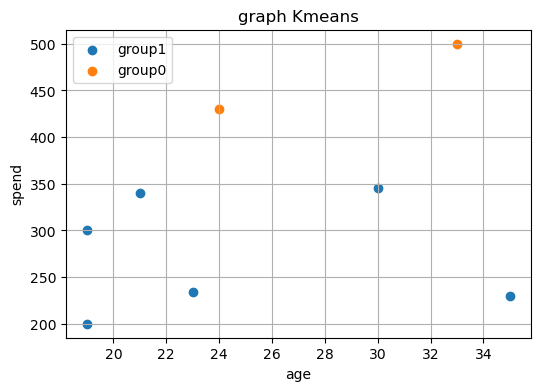

  costomer  age  spending  group
0  Bhushan   19       200      1
1     Yash   19       300      1
2    Ankit   21       340      1
3  Sushant   35       230      1
4   Sameer   33       500      0
5  Sandeep   24       430      0
6   Aakash   23       234      1
7  Pokemon   30       345      1


In [47]:
plt.figure(figsize=(6,4))
for g in df['group'].unique():
    grouped_data = df[df['group']==g]
    plt.scatter(grouped_data['age'],grouped_data['spending'],label=f'group{g}')
plt.xlabel("age")
plt.ylabel("spend")
plt.title("graph Kmeans")
plt.legend()
plt.grid(True)
plt.show()
print(df)

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
np.random.seed(42)

# Sample customer names
names = [
    'Bhushan', 'Yash', 'Ankit', 'Sushant', 'Sameer',
    'Sandeep', 'Aakash', 'Pokemon', 'Rahul', 'Rohit',
    'Aman', 'Kunal', 'Vikas', 'Neha', 'Pooja',
    'Riya', 'Sneha', 'Aditi', 'Karan', 'Nikhil'
]

# Generate large-scale dataset
n = 1000   # Number of rows

data = {
    'customer': np.random.choice(names, n),
    'age': np.random.randint(18, 60, n),
    'spending': np.random.randint(100, 1000, n)
}

df = pd.DataFrame(data)

print(df.head())
print("\nTotal Rows:", len(df))

  customer  age  spending
0   Aakash   24       696
1   Nikhil   35       757
2    Pooja   44       934
3     Aman   51       653
4  Pokemon   44       473

Total Rows: 1000


In [22]:
x=df[['age','spending']]

In [23]:
model=KMeans(n_clusters=3, random_state=42, n_init=10)

In [24]:
df['group']=model.fit_predict(x)

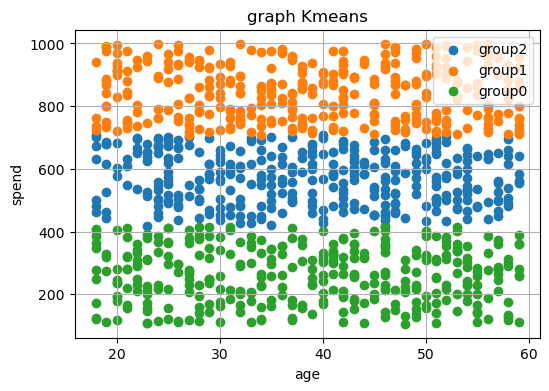

    customer  age  spending  group
0     Aakash   24       696      2
1     Nikhil   35       757      1
2      Pooja   44       934      1
3       Aman   51       653      2
4    Pokemon   44       473      2
..       ...  ...       ...    ...
995    Ankit   30       174      0
996   Nikhil   42       378      0
997     Aman   19       275      0
998  Sandeep   52       995      1
999     Yash   24       761      1

[1000 rows x 4 columns]


In [25]:
plt.figure(figsize=(6,4))
for g in df['group'].unique():
    grouped_data = df[df['group']==g]
    plt.scatter(grouped_data['age'],grouped_data['spending'],label=f'group{g}')
plt.xlabel("age")
plt.ylabel("spend")
plt.title("graph Kmeans")
plt.legend()
plt.grid(True)
plt.show()
print(df)

#
#
# **`I was Waiting for toy !`**

#
# `PCA`
#

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
df=pd.DataFrame({
    "age":[20,23,24,30,27,30,29],
    "income":[20000,22000,25000,40000,26000,40000,38000],
    "spending":[500,550,600,1000,650,1200,900],
    "saving":[1000,1300,1500,3000,1600,4000,2500]
})
df

,age,income,spending,saving
0,20,20000,500,1000
1,23,22000,550,1300
2,24,25000,600,1500
3,30,40000,1000,3000
4,27,26000,650,1600
5,30,40000,1200,4000
6,29,38000,900,2500


In [4]:
# df=pd.DataFrame({
#     "age":[20,23,24,30,27,30,29],
#     'department':["it","ai","it","it","ai","it","it"],
#     "income":[20000,22000,25000,40000,26000,40000,38000],
#     "spending":[500,550,600,1000,650,1200,900],
#     "saving":[1000,1300,1500,3000,1600,4000,2500]
# })
# df

# df.groupby(["department","age"])["income"].mean()


# df.groupby(["department"])["spending"].mean()


In [5]:
sdl=StandardScaler()

In [6]:
scaled_data=sdl.fit_transform(df)

In [7]:
scaled_data

array([[-1.70506091, -1.23933599, -1.10904597, -1.12581769],
       [-0.87235674, -0.99495988, -0.90474803, -0.8265497 ],
       [-0.59478869, -0.62839571, -0.70045009, -0.6270377 ],
       [ 1.07061964,  1.20442511,  0.93393345,  0.86930227],
       [ 0.23791548, -0.50620766, -0.49615214, -0.5272817 ],
       [ 1.07061964,  1.20442511,  1.75112522,  1.86686225],
       [ 0.79305159,  0.960049  ,  0.52533756,  0.37052228]])

In [12]:
pca=PCA(n_components=2)
pca_result=pca.fit_transform(scaled_data)

In [13]:
pca_df=pd.DataFrame(pca_result, columns=['PCA 1','PCA 2'])

In [14]:
explained_veriance=pca.explained_variance_ratio_

In [15]:
print(np.round(explained_veriance * 100 , 2))

[94.95  3.95]


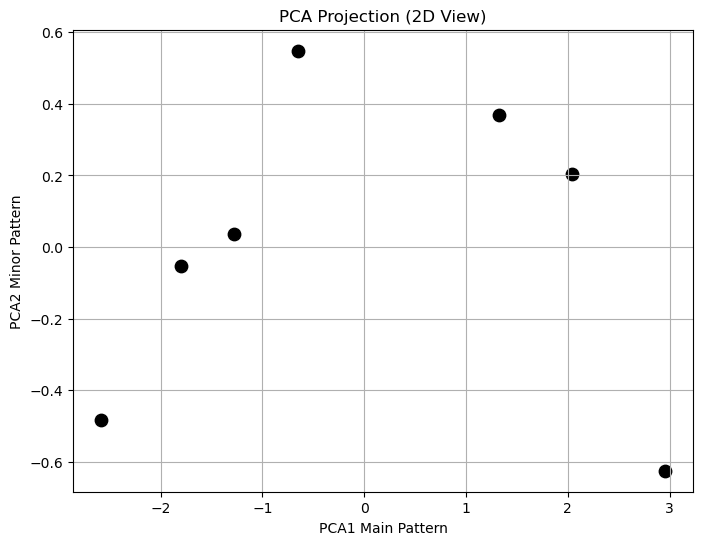

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PCA 1'], pca_df['PCA 2'], color='black', s=80)

plt.title("PCA Projection (2D View)")
plt.xlabel("PCA1 Main Pattern")
plt.ylabel("PCA2 Minor Pattern")

plt.grid(True)
plt.show()

#
#
# **`Heyyooo There is something for uhhh`**

#
# `Mini Project`
#

In [9]:
import pandas as pd

In [10]:
df=pd.read_csv("student_data.csv")
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


In [11]:
print(f"Rows ==> {df.shape[0]}, columns ==> {df.shape[1]}")

Rows ==> 20, columns ==> 6


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   StudyHours  20 non-null     int64 
 1   Attendance  20 non-null     int64 
 2   PastScore   20 non-null     int64 
 3   Internet    20 non-null     object
 4   SleepHours  20 non-null     int64 
 5   Passed      20 non-null     object
dtypes: int64(4), object(2)
memory usage: 1.1+ KB


In [13]:
df.describe()

,StudyHours,Attendance,PastScore,SleepHours
count,20.000000,20.000000,20.00000,20.000000
mean,5.100000,74.150000,59.10000,6.050000
std,2.845125,17.372922,19.41215,2.038446
min,1.000000,40.000000,25.00000,3.000000
25%,2.750000,60.000000,43.75000,4.750000
50%,5.000000,77.000000,62.50000,6.000000
75%,7.250000,88.500000,72.75000,7.250000
max,10.000000,99.000000,90.00000,10.000000


In [14]:
df.isnull().sum() * 100

StudyHours    0
Attendance    0
PastScore     0
Internet      0
SleepHours    0
Passed        0
dtype: int64

In [15]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [16]:
df=pd.read_csv("student_data.csv")
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


In [17]:
le=LabelEncoder()

In [18]:
df['Internet']=le.fit_transform(df['Internet'])
df['Passed']=le.fit_transform(df['Passed'])

In [19]:
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


#
# `Let's Start`
#

In [20]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df=pd.read_csv("student_data.csv")
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,Yes,5,No
1,5,80,60,No,6,Yes
2,8,90,75,Yes,8,Yes
3,3,70,50,Yes,5,No
4,7,85,70,No,7,Yes


In [22]:
le=LabelEncoder()
df['Internet']=le.fit_transform(df['Internet'])
df['Passed']=le.fit_transform(df['Passed'])
df.head()

,StudyHours,Attendance,PastScore,Internet,SleepHours,Passed
0,2,60,40,1,5,0
1,5,80,60,0,6,1
2,8,90,75,1,8,1
3,3,70,50,1,5,0
4,7,85,70,0,7,1


In [23]:
feature=['StudyHours','Attendance','PastScore','SleepHours']
sdl=StandardScaler()
dfc=df.copy()
dfc[feature]=sdl.fit_transform(df[feature])

In [24]:
X=dfc[feature]
y=dfc['Passed']
X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42)

In [25]:
model=LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred=model.predict(X_test)

In [27]:
print(classification_report(y_test,y_pred))
cnfuse_matrix=confusion_matrix(y_test,y_pred)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



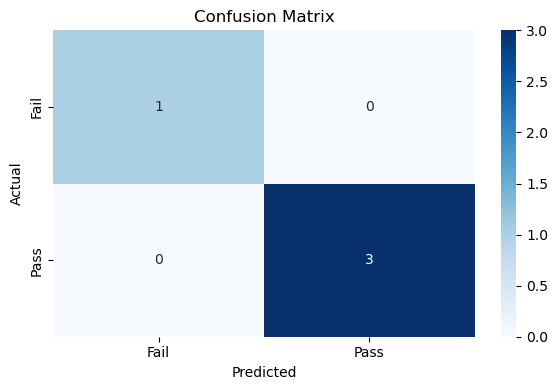

In [28]:

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cnfuse_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [31]:
try:
    study_hours = float(input("Enter study hours: "))
    attendance = float(input("Enter attendance: "))
    past_score = float(input("Enter past score: "))
    sleep_hours = float(input("Enter sleep hours: "))

    user_input_df = pd.DataFrame([{
        'StudyHours': study_hours,
        'Attendance': attendance,
        'PastScore': past_score,
        'SleepHours': sleep_hours
    }])

    # Scale the input using the same scaler used during training
    user_input_scaled = sdl.transform(user_input_df)

    # Predict
    prediction = model.predict(user_input_scaled)[0]

    result = "Pass" if prediction == 1 else "Fail"

    print(f"\nPrediction Based on Input: {result}")

except Exception as e:
    print("An error occurred:", e)

Enter study hours:  5
Enter attendance:  90
Enter past score:  90
Enter sleep hours:  5



Prediction Based on Input: Pass


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
